# **PHYSHING DECTATION**


In [43]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib 

from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,classification_report,accuracy_score,
    precision_score,recall_score,f1_score
    )

In [4]:
df=pd.read_csv('Phishing_URL_Dataset.csv')
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [5]:
df.shape

(235795, 56)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation           

In [7]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [8]:
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 0


In [9]:
print(df['label'].value_counts(normalize=True))

label
1    0.571895
0    0.428105
Name: proportion, dtype: float64


In [10]:
print("Total row:",len(df))
print("number of repeatation of url in dataset:",df['URL'].duplicated().sum())
print("unique URL:",df['URL'].nunique())

Total row: 235795
number of repeatation of url in dataset: 425
unique URL: 235370


In [11]:
# checking if duplicated url have the same label.
duplicate_url=df[df['URL'].duplicated(keep=False)].sort_values('URL')
print(
    duplicate_url.groupby('URL')['label'].nunique().value_counts()
)

label
1    425
Name: count, dtype: int64


In [12]:
#Removing repeated urls
df=df.drop_duplicates(subset='URL').reset_index(drop=True)
print("Rows after removing duplicate URL: ",len(df))

Rows after removing duplicate URL:  235370


<class 'pandas.DataFrame'>
(51, 1)


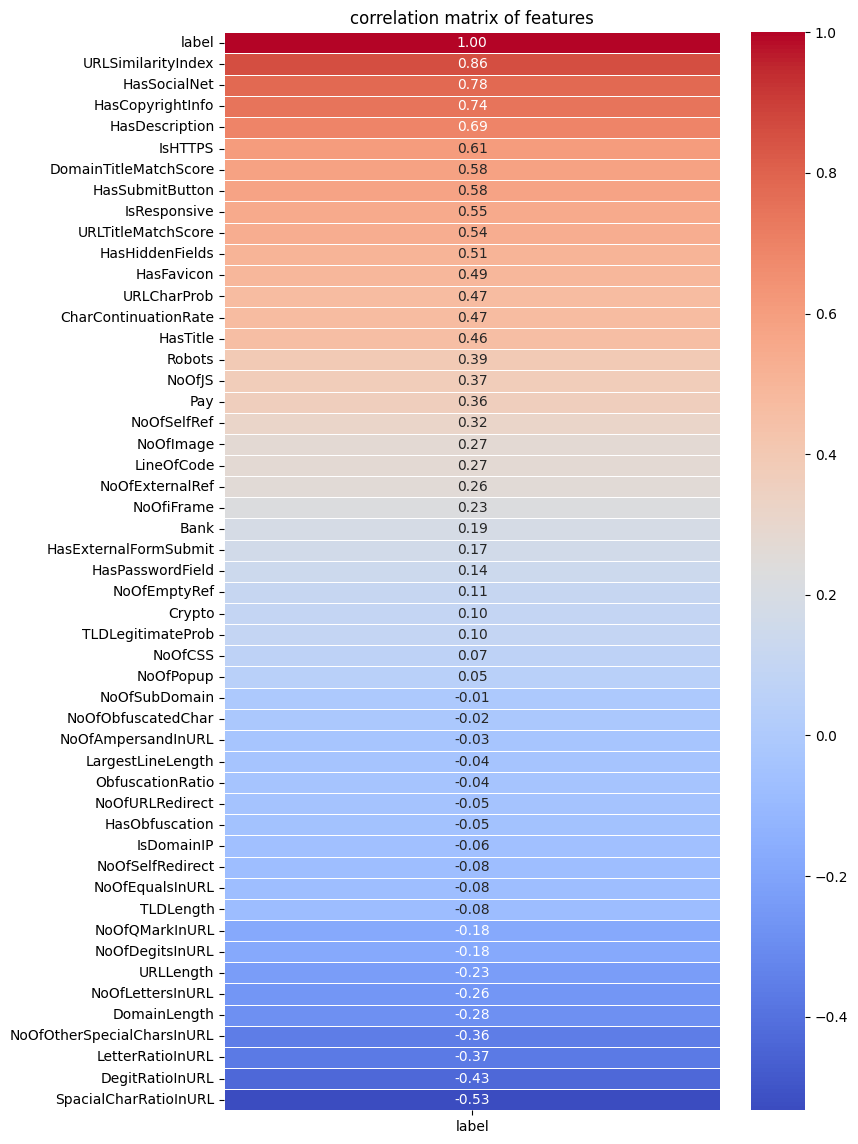

In [15]:
corr_with_label = df.corr(numeric_only=True)[['label']].sort_values(by='label',ascending=False)
print(type(corr_with_label))
print(corr_with_label.shape)

#ploting heatmap 

plt.figure(figsize=(8,14))
sns.heatmap(corr_with_label,annot=True, cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('correlation matrix of features')
plt.show()

In [17]:
top_n= 16
X_url=corr_with_label.drop('label').head(top_n).index.tolist()
# list of features we will use to train our model 
print("Selected features :\n",X_url)
target=df["label"]

Selected features :
 ['URLSimilarityIndex', 'HasSocialNet', 'HasCopyrightInfo', 'HasDescription', 'IsHTTPS', 'DomainTitleMatchScore', 'HasSubmitButton', 'IsResponsive', 'URLTitleMatchScore', 'HasHiddenFields', 'HasFavicon', 'URLCharProb', 'CharContinuationRate', 'HasTitle', 'Robots', 'NoOfJS']


In [19]:
X=df[X_url]
y=target
print("shape of the feature variable X:",X.shape)
print("shape of the feature variable y:",y.shape)

shape of the feature variable X: (235370, 16)
shape of the feature variable y: (235370,)


In [20]:
x_train,x_test,y_train,y_test=train_test_split(X,y, test_size=0.30,random_state=42,stratify=y)
print("shape of traing data :",x_train.shape)
print("shape of test data :",x_test.shape)

shape of traing data : (164759, 16)
shape of test data : (70611, 16)


In [21]:
x_train.columns

Index(['URLSimilarityIndex', 'HasSocialNet', 'HasCopyrightInfo',
       'HasDescription', 'IsHTTPS', 'DomainTitleMatchScore', 'HasSubmitButton',
       'IsResponsive', 'URLTitleMatchScore', 'HasHiddenFields', 'HasFavicon',
       'URLCharProb', 'CharContinuationRate', 'HasTitle', 'Robots', 'NoOfJS'],
      dtype='str')

## **6.Feature scaling**

In [22]:
scaler=StandardScaler()
x_train_sc=scaler.fit_transform(x_train)
x_test_sc=scaler.transform(x_test)

In [24]:
lr=LogisticRegression(max_iter=1000)
cv_score_lr=cross_val_score(lr, x_train_sc, y_train, cv=5, scoring='accuracy')
print("LR-5 fold cv accuracy: %.4f +/- %.4f "%(cv_score_lr.mean(),cv_score_lr.std()))



LR-5 fold cv accuracy: 0.9998 +/- 0.0001 


In [39]:
lr.fit(x_train_sc,y_train)
y_pred_lr=lr.predict(x_test_sc)


In [40]:
cm_lr=confusion_matrix(y_test,y_pred_lr)
print("confusion_matrix(logistic regression):\n",cm_lr)

print("\nClassification report(logistic regression) :\n",classification_report(y_test,y_pred_lr))

confusion_matrix(logistic regression):
 [[30140    16]
 [    0 40455]]

Classification report(logistic regression) :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     30156
           1       1.00      1.00      1.00     40455

    accuracy                           1.00     70611
   macro avg       1.00      1.00      1.00     70611
weighted avg       1.00      1.00      1.00     70611



## **K-nearest neighbours**

In [30]:
knn_param_grid={'n_neighbors':[3,5,7,9,11]}
knn_grid=GridSearchCV(KNeighborsClassifier(),knn_param_grid,cv=5,scoring='accuracy')
knn_grid.fit(x_train_sc,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [31]:
print('Best n_neighbors:',knn_grid.best_params_)
knn=knn_grid.best_estimator_
y_pred_knn=knn.predict(x_test_sc)

Best n_neighbors: {'n_neighbors': 3}


In [ ]:
cm_knn=confusion_matrix(y_test,y_pred_knn)
print("confusion_matrix(knn):\n",cm_knn)

print("Classification report(knn) :\n",classification_report(y_test,y_pred_knn))

confusion_matrix(knn):
 [[30087    69]
 [    9 40446]]
Classification report(knn) :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     30156
           1       1.00      1.00      1.00     40455

    accuracy                           1.00     70611
   macro avg       1.00      1.00      1.00     70611
weighted avg       1.00      1.00      1.00     70611



In [33]:
rf_param_grid={
    'n_estimators':[200,300],
    'max_depth':[None,10,20],
    'min_samples_leaf':[1,2,4]
}
rf_grid=GridSearchCV(
    RandomForestClassifier(random_state=42),rf_param_grid,cv=5,scoring='accuracy',n_jobs=-1
)
rf_grid.fit(x_train,y_train)
rf_model=rf_grid.best_estimator_
y_pred_rf=rf_model.predict(x_test)

In [35]:
cm_rf=confusion_matrix(y_test,y_pred_rf)
print("confusion_matrix(knn):\n",cm_rf)

print("Classification report(knn) :\n",classification_report(y_test,y_pred_rf))


confusion_matrix(knn):
 [[30152     4]
 [    0 40455]]
Classification report(knn) :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     30156
           1       1.00      1.00      1.00     40455

    accuracy                           1.00     70611
   macro avg       1.00      1.00      1.00     70611
weighted avg       1.00      1.00      1.00     70611



## **features importance** 

URLSimilarityIndex       0.352754
NoOfJS                   0.226851
HasSocialNet             0.144905
HasCopyrightInfo         0.090003
HasDescription           0.060615
IsHTTPS                  0.046006
HasSubmitButton          0.026461
DomainTitleMatchScore    0.022150
URLCharProb              0.007669
URLTitleMatchScore       0.005799
IsResponsive             0.005408
CharContinuationRate     0.004251
HasHiddenFields          0.003842
HasFavicon               0.002168
HasTitle                 0.000842
Robots                   0.000277
dtype: float64


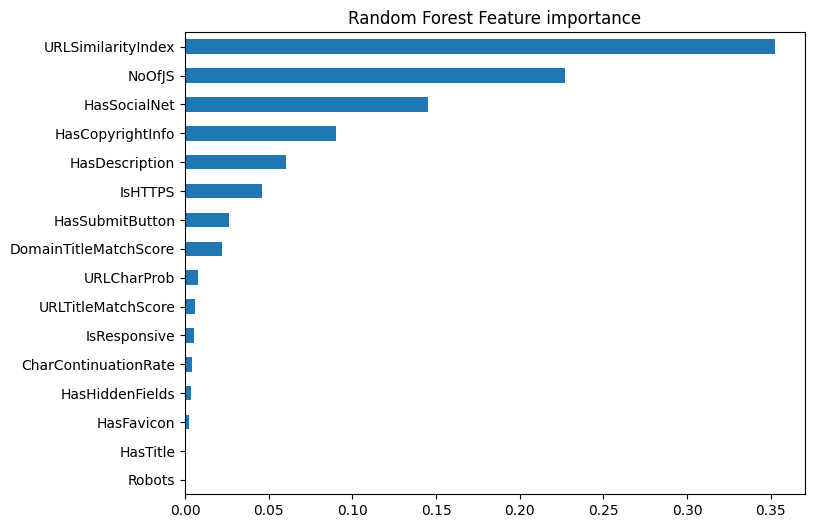

In [37]:
importance = pd.Series(rf_model.feature_importances_,index=X_url).sort_values(ascending=False)
print(importance)
plt.figure(figsize=(8,6))
importance.plot(kind='barh')
plt.title('Random Forest Feature importance')
plt.gca().invert_yaxis()
plt.show()

## **Model Comperison**

In [46]:
def summarize(name,y_true,y_pred):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision' : recall_score(y_true,y_pred),
        'f1': f1_score(y_true,y_pred)
    }

result = pd.DataFrame([
    summarize('Logistic Regression', y_test, y_pred_lr),
    summarize('KNN',y_test,y_pred_knn),
    summarize('Random Forest',y_test,y_pred_rf)
]).set_index('model')

print(result.round(4))

                     accuracy  precision      f1
model                                           
Logistic Regression    0.9998     1.0000  0.9998
KNN                    0.9989     0.9998  0.9990
Random Forest          0.9999     1.0000  1.0000


## **Save the best model**

In [47]:
best_model_name=result['f1'].idxmax()
print('Best model bel f1 score:',best_model_name)

#Random forest doesn't need the scaler;if LR or KNN wins instead.
#save the fitted scaler alongside the model so inference stays consistent.
joblib.dump(rf_model,'phishing_rf_model.pkl')

Best model bel f1 score: Random Forest


['phishing_rf_model.pkl']